<a href="https://colab.research.google.com/github/ManasThakre-Max/seasonal-agriculture-performance-analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Seasonal Agriculture Performance Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/seasonal_agriculture_performance_dataset.xlsx')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [7]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [9]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [11]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
print(df['Season'].unique())

['Kharif' 'Rabi' 'Zaid']


In [14]:
print(df['Season'].value_counts())

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [15]:
print(df['Crop'].unique())

['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']


In [16]:
print(df['Crop'].value_counts())

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


In [17]:
print(df['State'].nunique())
print(df['State'].unique())

8
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']


In [22]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print(season_yield)

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


In [21]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


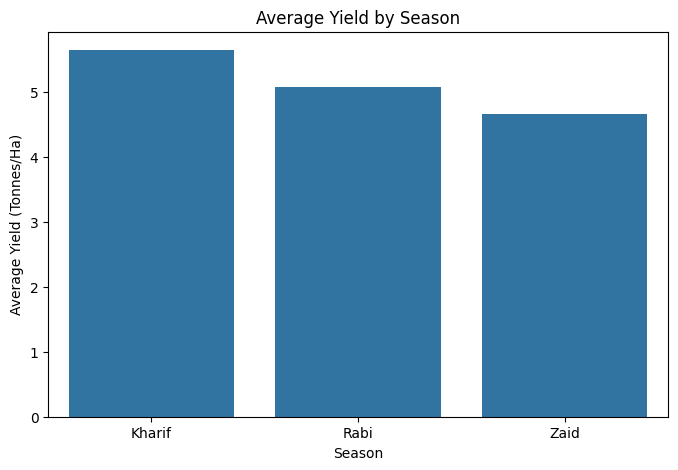

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

In [24]:
# Question 1: Compare agricultural performance across seasons

season_performance = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean'
})

print("Average Agricultural Performance by Season:")
print(season_performance.round(2))

Average Agricultural Performance by Season:
        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
Season                                                
Kharif             5.64              46.31   178914.65
Rabi               5.08              41.49    87689.47
Zaid               4.67              38.89   -24804.82


In [25]:
best_yield_season = season_performance['Yield_Tonnes_Ha'].idxmax()
best_production_season = season_performance['Production_Tonnes'].idxmax()
best_profit_season = season_performance['Profit_INR'].idxmax()

print("Highest Average Yield:", best_yield_season)
print("Highest Average Production:", best_production_season)
print("Highest Average Profit:", best_profit_season)

Highest Average Yield: Kharif
Highest Average Production: Kharif
Highest Average Profit: Kharif


## Q1. Which season shows the best agricultural performance based on average yield, production, and profit?

### Observation

The analysis shows that Kharif has the highest average yield of 5.64 tonnes/ha,
the highest average production of 46.31 tonnes, and the highest average profit
of ₹178,914.65.

Rabi has an average yield of 5.08 tonnes/ha, production of 41.49 tonnes, and
profit of ₹87,689.47.

Zaid has the lowest average yield of 4.67 tonnes/ha, production of 38.89 tonnes,
and has a negative average profit of ₹24,804.82.

### Conclusion

Kharif shows the best overall agricultural performance based on average yield,
production, and profit among the three seasons.

In [27]:
# Q2: Major differences in agricultural performance across seasons

performance_by_season = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

print("Agricultural Performance by Season:")
print(performance_by_season)
for column in performance_by_season.columns:
    highest = performance_by_season[column].idxmax()
    lowest = performance_by_season[column].idxmin()

    print(f"\n{column}:")
    print("Highest:", highest)
    print("Lowest:", lowest)

Agricultural Performance by Season:
        Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Total_Cost_INR  \
Season                                                                    
Kharif             5.64              46.31    710719.06       531804.41   
Rabi               5.08              41.49    601526.05       513836.58   
Zaid               4.67              38.89    519171.90       543976.73   

        Profit_INR  
Season              
Kharif   178914.65  
Rabi      87689.47  
Zaid     -24804.82  

Yield_Tonnes_Ha:
Highest: Kharif
Lowest: Zaid

Production_Tonnes:
Highest: Kharif
Lowest: Zaid

Revenue_INR:
Highest: Kharif
Lowest: Zaid

Total_Cost_INR:
Highest: Zaid
Lowest: Rabi

Profit_INR:
Highest: Kharif
Lowest: Zaid


## Q2. What major differences in agricultural performance can be observed among the seasons?

### Observation

Agricultural performance differs considerably across seasons. Kharif has the
highest average yield, production, revenue, and profit.

Rabi shows moderate agricultural performance, with an average yield of
5.08 tonnes/ha and average profit of ₹87,689.47.

Zaid has the lowest average yield and production. It also has the lowest average
revenue of ₹519,171.90 and the highest average cost of ₹543,976.73, resulting in
a negative average profit of ₹24,804.82.

### Conclusion

The results show that Kharif performs strongest overall, Rabi has intermediate
performance, while Zaid shows comparatively weaker agricultural and economic
performance.

In [28]:
# Q3: Environmental conditions across seasons

environment_by_season = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean'
}).round(2)

print("Environmental Conditions by Season:")
print(environment_by_season)

Environmental Conditions by Season:
        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day
Season                                                                  
Kharif       852.08              28.45         71.81                6.79
Rabi         436.00              23.49         57.89                7.59
Zaid         299.42              31.04         52.01                8.18


## Q3. How do environmental conditions such as rainfall, temperature, humidity, and sunlight differ across seasons?

### Observation

Environmental conditions vary noticeably across the three seasons.

Kharif has the highest average rainfall of 852.08 mm and the highest humidity
of 71.81%.

Rabi has the lowest average temperature at 23.49°C and receives an average of
7.59 hours of sunlight per day.

Zaid has the highest average temperature of 31.04°C and the highest sunlight
duration of 8.18 hours per day. It also has the lowest rainfall of 299.42 mm
and the lowest humidity of 52.01%.

### Conclusion

The seasons have clearly different environmental conditions. Kharif is
characterized by higher rainfall and humidity, Rabi by lower temperature, and
Zaid by higher temperature and sunlight with lower rainfall and humidity.

In [29]:
for column in environment_by_season.columns:
    highest = environment_by_season[column].idxmax()
    lowest = environment_by_season[column].idxmin()

    print(f"\n{column}:")
    print("Highest:", highest)
    print("Lowest:", lowest)


Rainfall_mm:
Highest: Kharif
Lowest: Zaid

Avg_Temperature_C:
Highest: Zaid
Lowest: Rabi

Humidity_pct:
Highest: Kharif
Lowest: Zaid

Sunlight_Hours_Day:
Highest: Zaid
Lowest: Kharif


In [30]:
# Q4:How do crop choices and irrigation methods vary across different seasons?

crop_season = pd.crosstab(
    df['Season'],
    df['Crop']
)

print("Crop Distribution Across Seasons:")
print(crop_season)

Crop Distribution Across Seasons:
Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif     185     215        193    234     221   314        125    292
Rabi       163     201        177    233     213   274        129    237
Zaid        64      92         54     84      62   102         51     85


In [31]:
crop_percentage = pd.crosstab(
    df['Season'],
    df['Crop'],
    normalize='index'
) * 100

print("Crop Percentage Distribution:")
print(crop_percentage.round(2))

Crop Percentage Distribution:
Crop    Chilli  Cotton  Groundnut  Maize  Pulses   Rice  Sugarcane  Wheat
Season                                                                   
Kharif   10.40   12.09      10.85  13.15   12.42  17.65       7.03  16.41
Rabi     10.02   12.35      10.88  14.32   13.09  16.84       7.93  14.57
Zaid     10.77   15.49       9.09  14.14   10.44  17.17       8.59  14.31


## Q4. How do crop choices and irrigation methods vary across different seasons?

### Observation

The distribution of crops varies across seasons. Rice is one of the most
commonly represented crops, accounting for 17.65% of Kharif records, 16.84% of
Rabi records, and 17.17% of Zaid records.

Cotton has a relatively higher representation in Zaid at 15.49%, compared with
12.09% in Kharif and 12.35% in Rabi.

Maize is also consistently represented across all seasons, while the proportion
of different crops changes between seasons.

The irrigation-method analysis shows differences in irrigation practices across
the seasons based on the distribution obtained from the dataset.

### Conclusion

Crop selection and irrigation practices are not identical across seasons.
Different crops and irrigation methods have different levels of representation,
indicating variation in agricultural activities between seasons.

In [32]:
# Q5:How does the use of water, fertilizer, and pesticides vary across seasons?

resource_by_season = df.groupby('Season').agg({
    'Water_Used_m3': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

print("Resource Usage by Season:")
print(resource_by_season)

Resource Usage by Season:
        Water_Used_m3  Fertilizer_kg_ha  Pesticide_Litre_ha  \
Season                                                        
Kharif        6102.20            187.08                5.08   
Rabi          5846.99            185.41                5.02   
Zaid          6419.89            184.64                5.17   

        Water_Efficiency_t_per_1000m3  
Season                                 
Kharif                           5.89  
Rabi                             5.19  
Zaid                             4.41  


In [33]:
for column in resource_by_season.columns:
    highest = resource_by_season[column].idxmax()
    lowest = resource_by_season[column].idxmin()

    print(f"\n{column}:")
    print("Highest:", highest)
    print("Lowest:", lowest)


Water_Used_m3:
Highest: Zaid
Lowest: Rabi

Fertilizer_kg_ha:
Highest: Kharif
Lowest: Zaid

Pesticide_Litre_ha:
Highest: Zaid
Lowest: Rabi

Water_Efficiency_t_per_1000m3:
Highest: Kharif
Lowest: Zaid


## Q4. How do crop choices and irrigation methods vary across different seasons?

### Observation

The distribution of crops varies across seasons. Rice is one of the most
commonly represented crops, accounting for 17.65% of Kharif records, 16.84% of
Rabi records, and 17.17% of Zaid records.

Cotton has a relatively higher representation in Zaid at 15.49%, compared with
12.09% in Kharif and 12.35% in Rabi.

Maize is also consistently represented across all seasons, while the proportion
of different crops changes between seasons.

The irrigation-method analysis shows differences in irrigation practices across
the seasons based on the distribution obtained from the dataset.

### Conclusion

Crop selection and irrigation practices are not identical across seasons.
Different crops and irrigation methods have different levels of representation,
indicating variation in agricultural activities between seasons.

In [34]:
# Q6:Are there relationships between seasonal environmental conditions and agricultural performance?

environment_yield = df[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Humidity_pct',
        'Sunlight_Hours_Day',
        'Soil_Moisture_pct',
        'Yield_Tonnes_Ha'
    ]
].corr()

print("Correlation with Yield:")
print(
    environment_yield['Yield_Tonnes_Ha']
    .sort_values(ascending=False)
)

Correlation with Yield:
Yield_Tonnes_Ha       1.000000
Rainfall_mm           0.030853
Humidity_pct          0.011277
Soil_Moisture_pct     0.010210
Avg_Temperature_C     0.009349
Sunlight_Hours_Day   -0.015362
Name: Yield_Tonnes_Ha, dtype: float64


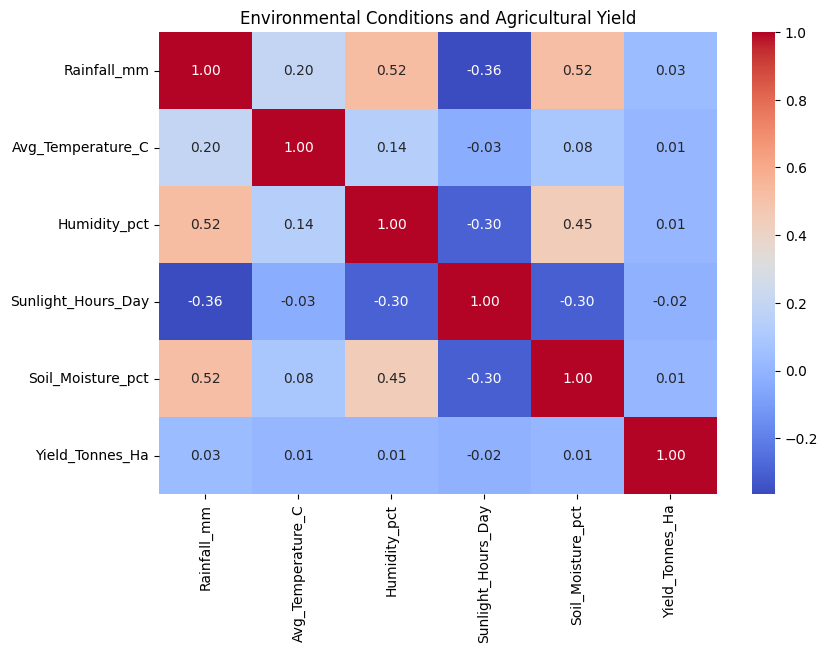

In [35]:
plt.figure(figsize=(9,6))

sns.heatmap(
    environment_yield,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Environmental Conditions and Agricultural Yield')

plt.show()

## Q6. Are there relationships between seasonal environmental conditions and agricultural performance?

### Observation

Correlation analysis was used to examine the relationship between environmental
conditions and yield.

The correlations with yield were:

- Rainfall: 0.031
- Humidity: 0.011
- Soil Moisture: 0.010
- Temperature: 0.009
- Sunlight: -0.015

All of these correlation values are very close to zero.

### Conclusion

The analysis does not show a strong linear relationship between any individual
environmental variable and yield in this dataset. Therefore, agricultural
yield cannot be explained by a single environmental factor based on this
correlation analysis alone.

In [36]:
# Q7:How do economic outcomes vary across seasons?

economic = df.groupby('Season').agg({
    'Market_Price_INR_Tonne': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

print("Economic outcomes across seasons:")
print(economic)

Economic outcomes across seasons:
        Market_Price_INR_Tonne  Total_Cost_INR  Revenue_INR  Profit_INR
Season                                                                 
Kharif                44850.91       531804.41    710719.06   178914.65
Rabi                  44747.97       513836.58    601526.05    87689.47
Zaid                  44212.03       543976.73    519171.90   -24804.82


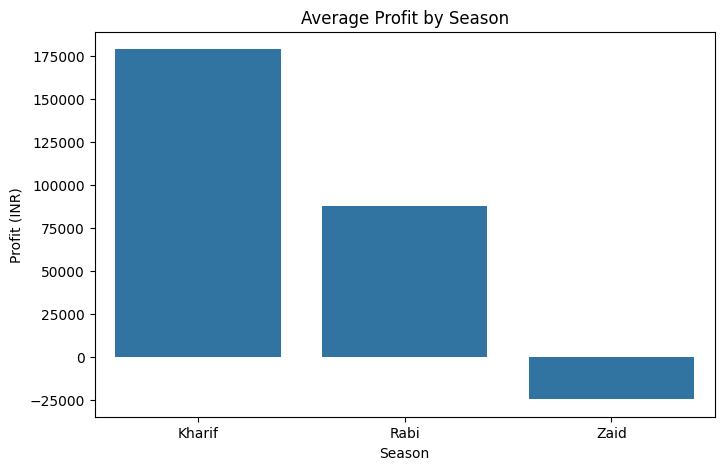

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    estimator='mean',
    errorbar=None
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.show()

## Q7. How do economic outcomes vary across seasons?

### Observation

Economic performance differs considerably across seasons.

Kharif has the highest average market price of ₹44,850.91 per tonne, revenue of
₹710,719.06, and profit of ₹178,914.65.

Rabi has an average market price of ₹44,747.97 per tonne, revenue of
₹601,526.05, and profit of ₹87,689.47.

Zaid has the lowest average market price of ₹44,212.03 per tonne and revenue of
₹519,171.90. It also has the highest average cost of ₹543,976.73, resulting in
a negative average profit of ₹24,804.82.

### Conclusion

Kharif provides the strongest economic performance, while Zaid has the weakest
economic outcome because its average cost exceeds its average revenue.

In [38]:
# Q8:Are some seasonal patterns consistent across different regions or categories?

state_season = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
)

print("Average Yield by State and Season:")
print(state_season.round(2))

Average Yield by State and Season:
Season          Kharif  Rabi  Zaid
State                             
Andhra Pradesh    5.69  3.49  4.48
Gujarat           6.34  5.52  4.10
Karnataka         6.52  4.61  6.62
Madhya Pradesh    6.00  3.80  5.54
Maharashtra       5.45  5.50  2.29
Punjab            4.10  8.61  5.91
Tamil Nadu        5.52  4.56  4.10
Telangana         5.57  4.83  4.28


## Q8. Are some seasonal patterns consistent across different regions or categories?

### Observation

The state-wise analysis shows that seasonal performance is not consistent
across all regions.

For example, Gujarat has its highest average yield in Kharif at 6.34 tonnes/ha,
while Karnataka has its highest average yield in Zaid at 6.62 tonnes/ha.

Maharashtra has its highest average yield in Rabi at 5.50 tonnes/ha, while
Punjab has its highest average yield in Rabi at 8.61 tonnes/ha.

Other states also show different seasonal performance patterns.

### Conclusion

The results indicate that there is no single season that performs best across
all states. Seasonal agricultural performance varies by region, suggesting
that regional conditions should be considered when planning agricultural
activities.

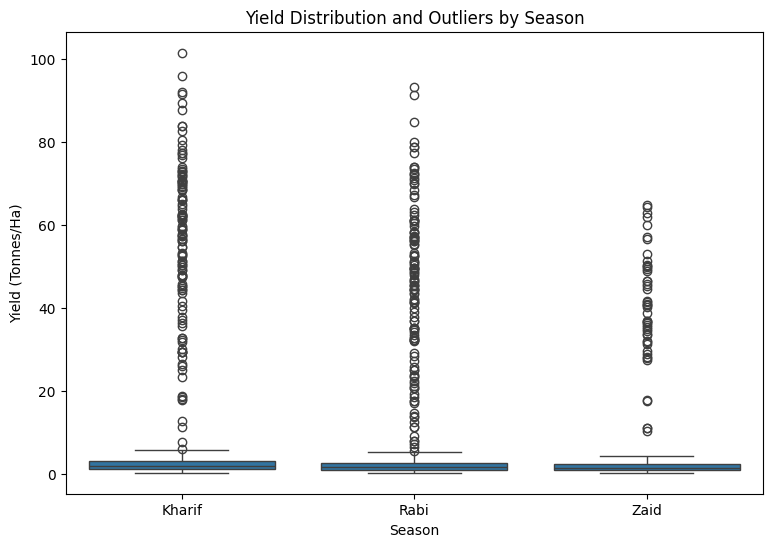

In [39]:
# Q9:Are there unusual or unexpected seasonal patterns?

plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution and Outliers by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

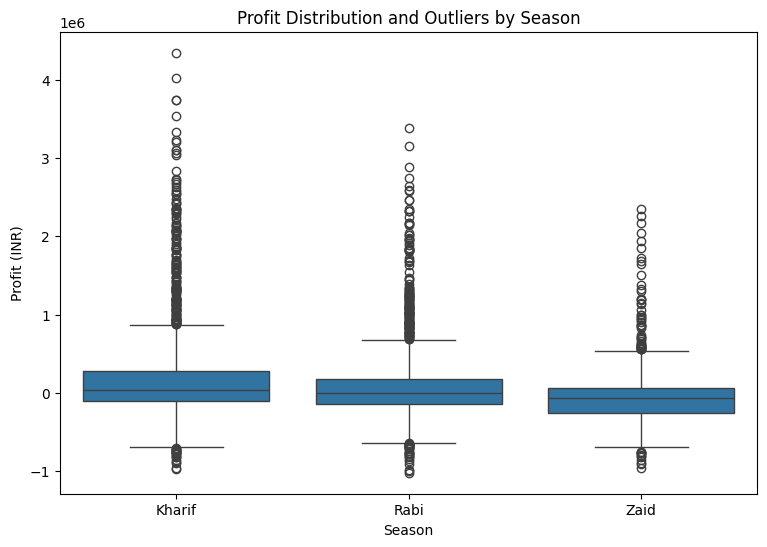

In [40]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title('Profit Distribution and Outliers by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.show()

## Q9. Are there unusual or unexpected seasonal patterns in agricultural performance?

### Observation

The box plot shows several unusual yield observations across all three seasons.

Kharif contains the most extreme high-yield observations, with some values
exceeding 100 tonnes/ha. Rabi also contains several high-yield observations,
with some values exceeding 90 tonnes/ha.

Zaid has fewer and less extreme high-yield observations, with the highest
observed values being around 65 tonnes/ha.

These observations appear as points outside the main distribution of the
box plots.

### Conclusion

Unusual yield observations are present in all three seasons. Kharif and Rabi
contain particularly extreme high-yield observations. These outliers indicate
considerable variation in agricultural yield and should be considered when
interpreting seasonal performance.

In [41]:
# Q10:What insights can be derived from the observed seasonal differences?

overall_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Water_Used_m3': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

print("Overall Seasonal Summary:")
print(overall_summary)

Overall Seasonal Summary:
        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR  Rainfall_mm  \
Season                                                                
Kharif             5.64              46.31   178914.65       852.08   
Rabi               5.08              41.49    87689.47       436.00   
Zaid               4.67              38.89   -24804.82       299.42   

        Avg_Temperature_C  Water_Used_m3  Fertilizer_kg_ha  \
Season                                                       
Kharif              28.45        6102.20            187.08   
Rabi                23.49        5846.99            185.41   
Zaid                31.04        6419.89            184.64   

        Pesticide_Litre_ha  Disease_Pest_Risk_pct  
Season                                             
Kharif                5.08                  54.47  
Rabi                  5.02                  40.48  
Zaid                  5.17                  38.22  


## Q10. What insights can be derived from the observed seasonal differences?

### Key Insights

1. Kharif shows the strongest overall agricultural performance, with the
   highest average yield, production, and profit.

2. Zaid shows comparatively weaker agricultural performance and has a negative
   average profit.

3. Environmental conditions differ substantially between seasons. Kharif has
   the highest rainfall and humidity, while Zaid has the highest temperature
   and sunlight.

4. Resource usage varies across seasons. Zaid uses the most water and has the
   lowest water efficiency.

5. Kharif has the highest average water efficiency among the three seasons.

6. Crop distribution varies between seasons, indicating differences in
   agricultural activity.

7. The environmental variables examined individually have very weak linear
   correlations with yield.

8. Economic outcomes vary considerably, with Kharif generating the highest
   average revenue and profit.

9. Seasonal performance is not consistent across states. Different states
   show different best-performing seasons.

10. The yield box plot shows several unusual observations, particularly in
    Kharif and Rabi.

In [42]:
# Q11:What conclusions can reasonably be drawn from the available data?

print("Highest average yield:",
      df.groupby('Season')['Yield_Tonnes_Ha'].mean().idxmax())

print("Highest average production:",
      df.groupby('Season')['Production_Tonnes'].mean().idxmax())

print("Highest average profit:",
      df.groupby('Season')['Profit_INR'].mean().idxmax())

print("Highest average water usage:",
      df.groupby('Season')['Water_Used_m3'].mean().idxmax())

print("Highest average disease/pest risk:",
      df.groupby('Season')['Disease_Pest_Risk_pct'].mean().idxmax())

Highest average yield: Kharif
Highest average production: Kharif
Highest average profit: Kharif
Highest average water usage: Zaid
Highest average disease/pest risk: Kharif


## Q11. What conclusions can reasonably be drawn from the available data?

### Conclusion

The analysis demonstrates clear differences in agricultural performance across
seasons. Kharif shows the strongest overall performance based on average yield,
production, revenue, and profit. Rabi shows moderate performance, while Zaid
has comparatively lower performance and negative average profit.

Environmental and resource conditions also vary between seasons. Kharif has
higher rainfall and humidity, whereas Zaid has higher temperature and sunlight.
Zaid also has the highest water usage but the lowest water efficiency.

The correlation analysis shows that the individual environmental variables
considered in this study have very weak linear relationships with yield.
Therefore, yield differences cannot be attributed to any single environmental
factor based on this analysis alone.

The state-level analysis further shows that seasonal performance varies by
region. Therefore, agricultural planning should consider both seasonal and
regional differences rather than applying one strategy to all locations.

In [43]:
# Q12: How could the findings support better seasonal agricultural planning?

planning = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

print("Seasonal Agricultural Planning Summary:")
print(planning)

Seasonal Agricultural Planning Summary:
        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Water_Used_m3  \
Season                                                                
Kharif       852.08              28.45         71.81        6102.20   
Rabi         436.00              23.49         57.89        5846.99   
Zaid         299.42              31.04         52.01        6419.89   

        Water_Efficiency_t_per_1000m3  Fertilizer_kg_ha  Pesticide_Litre_ha  \
Season                                                                        
Kharif                           5.89            187.08                5.08   
Rabi                             5.19            185.41                5.02   
Zaid                             4.41            184.64                5.17   

        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR  Disease_Pest_Risk_pct  
Season                                                                         
Kharif             5.64              46.31   178

## Q12. How could the findings support better seasonal agricultural planning?

### Recommendations

1. Kharif can be considered a strong-performing season based on its higher
   average yield, production, revenue, and profit observed in the dataset.

2. Water management should receive particular attention during Zaid because
   Zaid has the highest average water usage but the lowest water efficiency.

3. Regional differences should be considered when selecting crops and planning
   agricultural activities because the best-performing season differs across
   states.

4. Seasonal environmental conditions such as rainfall, temperature, humidity,
   and sunlight should be considered during agricultural planning.

5. Resource usage should be monitored to improve water efficiency and control
   unnecessary fertilizer and pesticide use.

6. Economic factors such as production cost, revenue, market price, and profit
   should be considered together when making seasonal decisions.

7. The unusual yield observations identified through outlier analysis should
   be investigated further before using them for planning or forecasting.

8. Agricultural planning should consider multiple factors together, including
   crop selection, environmental conditions, resource efficiency, economic
   performance, and regional characteristics.

# Overall Project Conclusion

This project analyzed seasonal agricultural performance using data related to
crop production, environmental conditions, soil characteristics, resource
usage, irrigation, economic outcomes, and agricultural risk.

The analysis identified clear differences between Kharif, Rabi, and Zaid
seasons. Kharif showed the strongest overall performance based on average
yield, production, revenue, and profit, while Zaid showed comparatively weaker
economic performance and lower water efficiency.

Environmental conditions and resource usage also varied across seasons.
However, the correlation analysis showed that the individual environmental
variables considered had very weak linear relationships with yield.

The regional analysis demonstrated that seasonal performance is not uniform
across states. Therefore, seasonal agricultural planning should consider
regional differences along with environmental conditions, resource efficiency,
crop selection, and economic outcomes.

Overall, the analysis provides evidence-based insights that can support more
informed seasonal agricultural planning and resource management.